In [1]:
# python -m pip install pandas matplotlib seaborn xlrd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Tabela 5 - participação de homens e mulheres entre os desocupados
t2012 = pd.read_csv("Tabela5-sem_emprego_2012.csv", sep=";", decimal=",", encoding="utf-8-sig")
t2026 = pd.read_csv("Tabela5-sem_emprego_2026.csv", sep=";", decimal=",", encoding="utf-8-sig")

t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})
t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})

display(t2012.head())
t2026.head()

,Sigla,Código,Estado,homens_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2


,Sigla,Código,Estado,homens_2026,mulheres_2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3


In [3]:
path_horas = r"..\atv3\Tabela 1.1.1.xls"

# Lê sem usar a 1ª linha como nome de coluna (senão o título vira coluna)
bruto = pd.read_excel(path_horas, engine="xlrd", header=None)

# Linhas 8 a 40: Brasil + 5 Regiões + 27 UFs (41+ = fonte e notas)
indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

indicador_1.head()

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986


In [4]:
# Só os estados: remove Brasil e as Grandes Regiões
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados_horas = (
    indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]
    .rename(columns={"uf_regiao": "Estado"})
    .reset_index(drop=True)
)

print("Linhas:", len(estados_horas))
estados_horas.head()

Linhas: 27


,Estado,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
1,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
2,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
4,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144


In [5]:
# Juntar as duas Tabelas 5
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")

# Cruzar com a Tabela 1.1.1 (horas de cuidados/afazeres por Estado)
comp = comp.merge(estados_horas, on="Estado", how="left")

print("Linhas:", len(comp), "| sem horas:", comp["total"].isna().sum())
comp.head()

Linhas: 27 | sem horas: 0


,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,AC,12,Acre,45.3,54.7,53.2,46.8,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,20.217129,19.165111,20.560451,12.121839,13.357160,24.093655,25.856637
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,AP,16,Amapá,48.1,51.9,51.1,48.9,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
4,BA,29,Bahia,43.8,56.2,44.7,55.3,17.849776,17.538007,17.935566,10.551673,10.982808,22.572730,23.217119


In [6]:
# Ordem do eixo Y: estados com mais participação feminina em 2026
ordem = comp.sort_values("mulheres_2026", ascending=False)["Estado"]

# Derreter (melt) as colunas de 2012 e 2026 para o formato longo
value_vars = ["mulheres_2012", "mulheres_2026"]

longo = comp.melt(
    id_vars=[c for c in comp.columns if c not in value_vars],
    value_vars=value_vars,
    var_name="Ano",
    value_name="Participacao_mulheres",
)

longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})
longo.head()

,Sigla,Código,Estado,homens_2012,homens_2026,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda,Ano,Participacao_mulheres
0,AC,12,Acre,45.3,53.2,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754,2012 T1,54.7
1,AL,27,Alagoas,44.7,50.7,20.217129,19.165111,20.560451,12.121839,13.357160,24.093655,25.856637,2012 T1,55.3
2,AM,13,Amazonas,47.5,46.8,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986,2012 T1,52.5
3,AP,16,Amapá,48.1,51.1,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487,2012 T1,51.9
4,BA,29,Bahia,43.8,44.7,17.849776,17.538007,17.935566,10.551673,10.982808,22.572730,23.217119,2012 T1,56.2


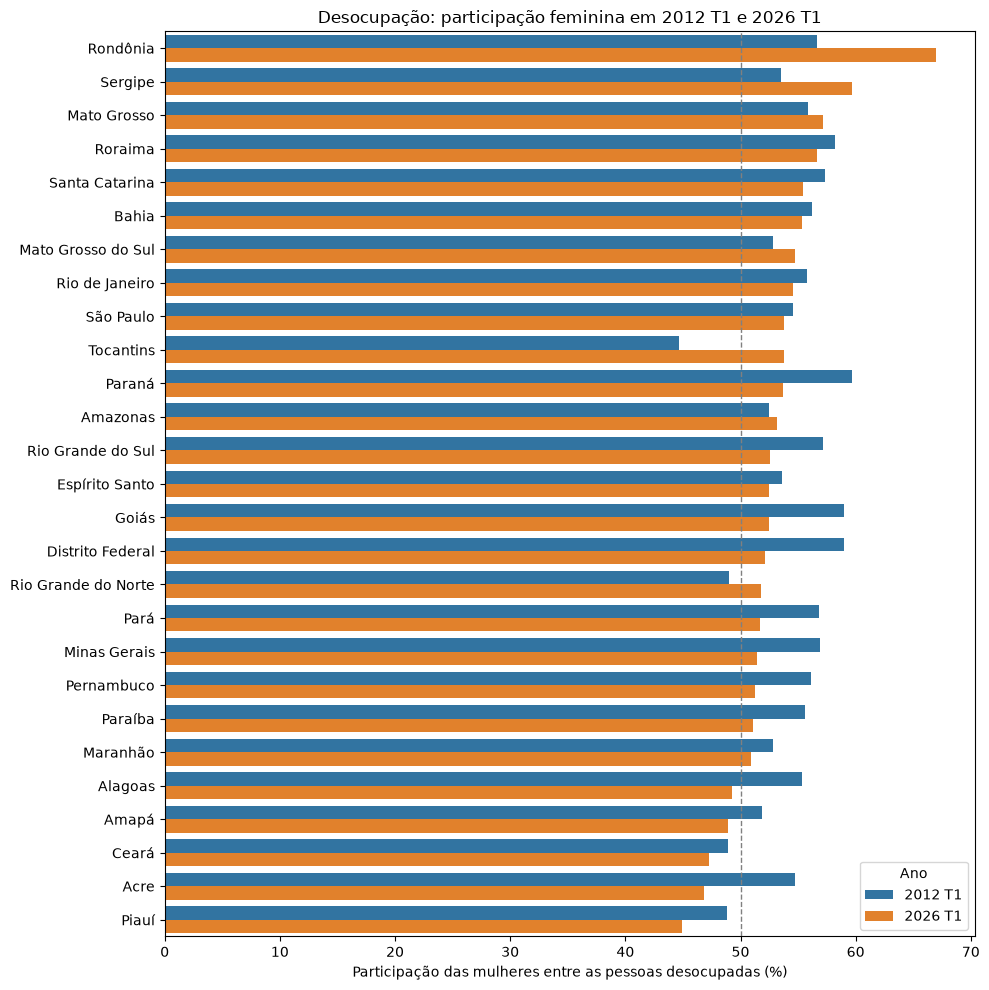

In [7]:
# Instanciar a figura
fig, ax = plt.subplots(figsize=(10, 10))

sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)

ax.axvline(50, color="gray", linestyle="--", linewidth=1)  # marca os 50%
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Ano")
fig.tight_layout()

# Mostrar o gráfico
plt.show()